<a href="https://colab.research.google.com/github/hridibazaman03/220142_CNN_RPS/blob/main/220142_CNN_RPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import random
import zipfile
import urllib.request
import subprocess
import copy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report

print("PyTorch version:", torch.__version__)
print("Torchvision version:", __import__("torchvision").__version__)

PyTorch version: 2.11.0+cpu


In [31]:
# ============================================================
# CELL 2: PROJECT CONFIGURATION
# ============================================================

GITHUB_REPO_URL = "https://github.com/hridibazaman03/220142_CNN_RPS.git"

REPO_DIR = "/content/220142_CNN_RPS"

CUSTOM_DATA_DIR = os.path.join(
    REPO_DIR,
    "dataset"
)

MODEL_DIR = os.path.join(
    REPO_DIR,
    "model"
)

MODEL_FILENAME = "rps_resnet18.pth"

MODEL_PATH = os.path.join(
    MODEL_DIR,
    MODEL_FILENAME
)

# Standard RPS dataset
DATA_ROOT = "/content/rps_dataset"

TRAIN_ZIP = "/content/rps_train.zip"
TEST_ZIP = "/content/rps_test.zip"

TRAIN_EXTRACT_DIR = "/content/rps_train"
TEST_EXTRACT_DIR = "/content/rps_test"

# ------------------------------------------------------------
# IMAGE SETTINGS
# ------------------------------------------------------------

IMAGE_SIZE = 224

# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

BATCH_SIZE = 32

NUM_EPOCHS = 15

LEARNING_RATE = 0.0001

NUM_CLASSES = 3

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)

Device: cpu
Image size: 128
Batch size: 32
Epochs: 15


In [32]:
# ============================================================
# CELL 3: CLONE GITHUB REPOSITORY
# ============================================================

if os.path.exists(REPO_DIR):

    print("Repository already exists.")
    print("Using:", REPO_DIR)

else:

    print("Cloning GitHub repository...")

    result = subprocess.run(
        [
            "git",
            "clone",
            GITHUB_REPO_URL,
            REPO_DIR
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:

        print(result.stderr)

        raise RuntimeError(
            "GitHub cloning failed. "
            "Check your repository URL."
        )

    print("Repository cloned successfully.")


print("\nRepository contents:")

for item in sorted(os.listdir(REPO_DIR)):
    print(" -", item)

Repository already exists.

Repository contents:
 - dataset
 - model
 - README.md
 - 220142_CNN_RPS.ipynb
 - .git


In [33]:
# ============================================================
# CELL 4: CHECK CUSTOM IMAGES
# ============================================================

if not os.path.exists(CUSTOM_DATA_DIR):

    raise FileNotFoundError(
        f"Dataset folder not found:\n{CUSTOM_DATA_DIR}"
    )


VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
)


custom_images = []

for filename in sorted(
    os.listdir(CUSTOM_DATA_DIR)
):

    if filename.lower().endswith(
        VALID_EXTENSIONS
    ):

        custom_images.append(
            os.path.join(
                CUSTOM_DATA_DIR,
                filename
            )
        )


print("Custom images found:", len(custom_images))

for path in custom_images:

    print(
        " -",
        os.path.basename(path)
    )


if len(custom_images) != 10:

    print(
        "\nWARNING:"
        f" Expected 10 images, found {len(custom_images)}."
    )

Custom images found: 10
 - paper1.jpg
 - paper2.jpg
 - paper3.jpg
 - rock1.jpg
 - rock2.jpg
 - rock3.jpg
 - scissors1.jpg
 - scissors2.jpg
 - scissors3.jpg
 - scissors4.jpg


In [34]:
# ============================================================
# CELL 5: DOWNLOAD STANDARD RPS DATASET
# ============================================================

TRAIN_URL = (
    "https://storage.googleapis.com/"
    "tensorflow-1-public/course2/week4/rps.zip"
)

TEST_URL = (
    "https://storage.googleapis.com/"
    "tensorflow-1-public/course2/week4/"
    "rps-test-set.zip"
)


def download_file(
    url,
    output_path
):

    if os.path.exists(output_path):

        print(
            "Already downloaded:",
            output_path
        )

        return


    print("Downloading:")
    print(url)

    urllib.request.urlretrieve(
        url,
        output_path
    )

    print(
        "Downloaded:",
        output_path
    )


download_file(
    TRAIN_URL,
    TRAIN_ZIP
)

download_file(
    TEST_URL,
    TEST_ZIP
)

print("\nRPS dataset downloaded.")

Already downloaded: /content/rps_train.zip
Already downloaded: /content/rps_test.zip
Dataset archives downloaded.


In [35]:
# ============================================================
# CELL 6: EXTRACT DATASET
# ============================================================

os.makedirs(
    TRAIN_EXTRACT_DIR,
    exist_ok=True
)

os.makedirs(
    TEST_EXTRACT_DIR,
    exist_ok=True
)


if not os.listdir(TRAIN_EXTRACT_DIR):

    with zipfile.ZipFile(
        TRAIN_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            TRAIN_EXTRACT_DIR
        )


if not os.listdir(TEST_EXTRACT_DIR):

    with zipfile.ZipFile(
        TEST_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            TEST_EXTRACT_DIR
        )


print("Training dataset extracted.")
print("Test dataset extracted.")

Training dataset extracted.
Test dataset extracted.


In [36]:
# ============================================================
# CELL 7: FIND DATASET DIRECTORIES
# ============================================================

def find_class_directory(
    root_dir
):

    for root, dirs, files in os.walk(
        root_dir
    ):

        directory_names = {
            d.lower()
            for d in dirs
        }

        if {
            "rock",
            "paper",
            "scissors"
        }.issubset(
            directory_names
        ):

            return root

    return None


TRAIN_DATA_DIR = find_class_directory(
    TRAIN_EXTRACT_DIR
)

TEST_DATA_DIR = find_class_directory(
    TEST_EXTRACT_DIR
)


if TRAIN_DATA_DIR is None:

    raise FileNotFoundError(
        "Training rock/paper/scissors folders "
        "could not be found."
    )


if TEST_DATA_DIR is None:

    raise FileNotFoundError(
        "Test rock/paper/scissors folders "
        "could not be found."
    )


print(
    "Training directory:",
    TRAIN_DATA_DIR
)

print(
    "Test directory:",
    TEST_DATA_DIR
)

Training directory:
/content/rps_train/rps

Test directory:
/content/rps_test/rps-test-set


In [37]:
# ============================================================
# CELL 8: DATA PREPROCESSING
# ============================================================

# ImageNet normalization because ResNet18
# was pretrained on ImageNet.

NORMALIZE_MEAN = [
    0.485,
    0.456,
    0.406
]

NORMALIZE_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------------------------------------
# TRAINING TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        NORMALIZE_MEAN,
        NORMALIZE_STD
    )
])


# ------------------------------------------------------------
# VALIDATION / TEST / CUSTOM TRANSFORM
# ------------------------------------------------------------

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        NORMALIZE_MEAN,
        NORMALIZE_STD
    )
])


print("Training transform created.")
print("Evaluation transform created.")

Transforms created successfully.


In [60]:
# ============================================================
# CELL 9: LOAD DATASETS
# ============================================================

full_train_dataset = datasets.ImageFolder(
    root=TRAIN_DATA_DIR,
    transform=train_transform
)


full_train_eval_dataset = datasets.ImageFolder(
    root=TRAIN_DATA_DIR,
    transform=eval_transform
)


test_dataset = datasets.ImageFolder(
    root=TEST_DATA_DIR,
    transform=eval_transform
)


# IMPORTANT:
# Automatically use ImageFolder's class order.

CLASS_NAMES = full_train_dataset.classes


print("Classes:")
print(CLASS_NAMES)

print("\nClass to index:")
print(full_train_dataset.class_to_idx)

print(
    "\nTraining images:",
    len(full_train_dataset)
)

print(
    "Test images:",
    len(test_dataset)
)

Classes: ['paper', 'rock', 'scissors']
Class to index: {'paper': 0, 'rock': 1, 'scissors': 2}

Training images: 2520
Test images: 372


In [61]:
# ============================================================
# CELL 10: TRAIN / VALIDATION SPLIT
# ============================================================

generator = torch.Generator()

generator.manual_seed(SEED)


indices = torch.randperm(
    len(full_train_dataset),
    generator=generator
).tolist()


train_size = int(
    0.80 * len(indices)
)


train_indices = indices[
    :train_size
]

val_indices = indices[
    train_size:
]


train_dataset = Subset(
    full_train_dataset,
    train_indices
)


val_dataset = Subset(
    full_train_eval_dataset,
    val_indices
)


print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

Training samples: 2016
Validation samples: 504
Test samples: 372


In [62]:
# ============================================================
# CELL 11: DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


print("DataLoaders created successfully.")

DataLoaders created.


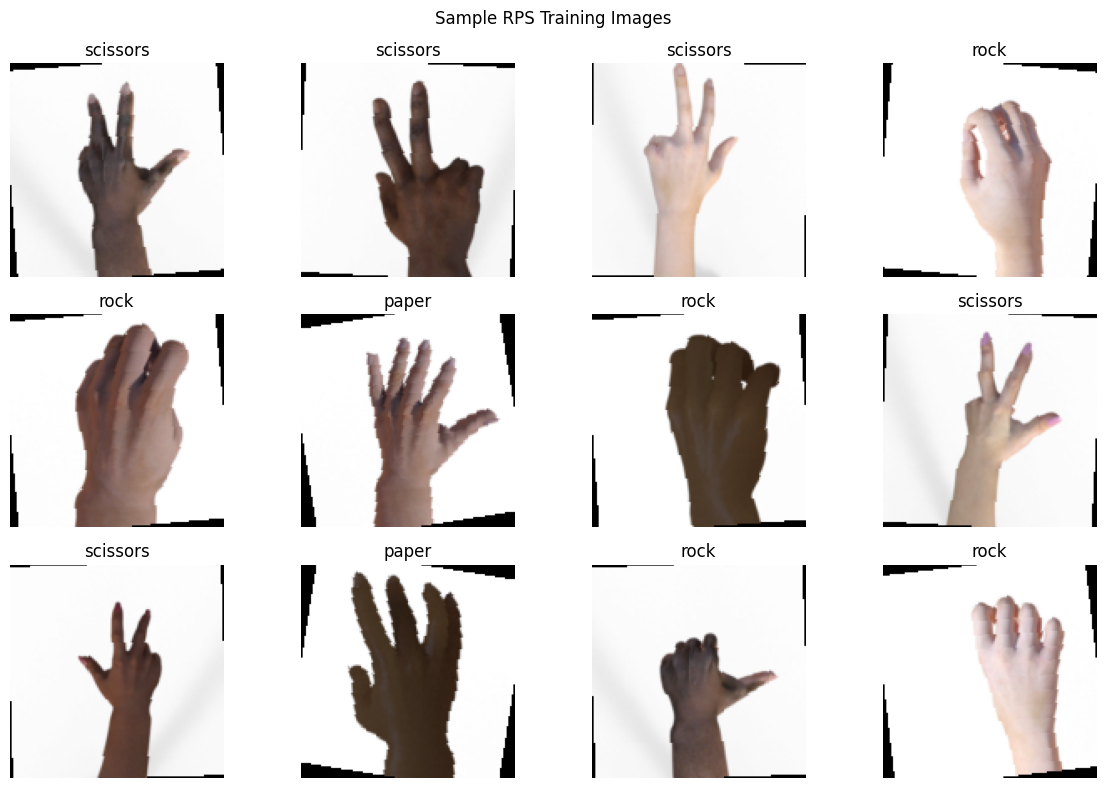

In [63]:
# ============================================================
# CELL 12: DISPLAY TRAINING IMAGES
# ============================================================

def denormalize(image):

    mean = torch.tensor(
        NORMALIZE_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        NORMALIZE_STD
    ).view(3, 1, 1)

    image = (
        image.cpu() * std + mean
    )

    return torch.clamp(
        image,
        0,
        1
    )


images, labels = next(
    iter(train_loader)
)


plt.figure(
    figsize=(12, 8)
)


for i in range(
    min(12, len(images))
):

    plt.subplot(
        3,
        4,
        i + 1
    )

    image = denormalize(
        images[i]
    )

    plt.imshow(
        image.permute(
            1,
            2,
            0
        )
    )

    plt.title(
        CLASS_NAMES[
            labels[i].item()
        ]
    )

    plt.axis("off")


plt.suptitle(
    "RPS Training Images"
)

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# CELL 13: RESNET18 CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(
        self,
        num_classes=3
    ):

        super(CNN, self).__init__()


        # Load pretrained ResNet18
        weights = models.ResNet18_Weights.DEFAULT

        self.resnet = models.resnet18(
            weights=weights
        )


        # ----------------------------------------------------
        # Initially freeze the pretrained backbone
        # ----------------------------------------------------

        for parameter in self.resnet.parameters():

            parameter.requires_grad = False


        # ----------------------------------------------------
        # Unfreeze the last ResNet block
        # This allows adaptation to RPS images.
        # ----------------------------------------------------

        for parameter in self.resnet.layer4.parameters():

            parameter.requires_grad = True


        # ----------------------------------------------------
        # Replace final ImageNet classifier
        # ----------------------------------------------------

        num_features = (
            self.resnet.fc.in_features
        )


        self.resnet.fc = nn.Sequential(

            nn.Dropout(
                p=0.4
            ),

            nn.Linear(
                num_features,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        return self.resnet(x)


model = CNN(
    NUM_CLASSES
).to(DEVICE)


print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [65]:
# ============================================================
# CELL 14: TRAINABLE PARAMETERS
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)


trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [66]:
# ============================================================
# CELL 15: LOSS FUNCTION + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=LEARNING_RATE
)


print("Loss:", criterion)
print("Optimizer:", optimizer)

In [67]:
# ============================================================
# CELL 16: TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )


        # Clear gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(
            images
        )


        # Loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        100 * correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )


def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        100 * correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )

SAVED MODEL FOUND
Model loaded from:
/content/220142_CNN_RPS/model/rps_cnn.pth


In [68]:
# ============================================================
# CELL 17: TRAIN RESNET18
# ============================================================

FORCE_TRAIN = True


os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


best_val_accuracy = 0.0


if (
    os.path.exists(MODEL_PATH)
    and not FORCE_TRAIN
):

    print("=" * 60)
    print("SAVED RESNET18 MODEL FOUND")
    print("=" * 60)


    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=DEVICE,
            weights_only=True
        )
    )


    model.to(DEVICE)


    print(
        "Model loaded from:"
    )

    print(MODEL_PATH)


else:

    print("=" * 60)
    print("TRAINING RESNET18")
    print("=" * 60)


    for epoch in range(
        NUM_EPOCHS
    ):


        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )


        val_loss, val_accuracy = evaluate(
            model,
            val_loader,
            criterion
        )


        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        train_accuracies.append(
            train_accuracy
        )

        val_accuracies.append(
            val_accuracy
        )


        print(
            f"Epoch "
            f"[{epoch + 1}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )


        # Save best model
        if (
            val_accuracy
            > best_val_accuracy
        ):

            best_val_accuracy = (
                val_accuracy
            )


            torch.save(
                model.state_dict(),
                MODEL_PATH
            )


            print(
                f"  Best model saved: "
                f"{best_val_accuracy:.2f}%"
            )


    # Load best model
    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=DEVICE,
            weights_only=True
        )
    )


    print("\nTraining complete.")

    print(
        "Best validation accuracy:",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Saved model:",
        MODEL_PATH
    )

Training history is not available because the model was loaded from an existing .pth file.


In [69]:
# ============================================================
# CELL 18: LOSS GRAPH
# ============================================================

if len(train_losses) > 0:

    epochs_range = range(
        1,
        len(train_losses) + 1
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs_range,
        train_losses,
        marker="o",
        label="Training Loss"
    )


    plt.plot(
        epochs_range,
        val_losses,
        marker="o",
        label="Validation Loss"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "Training and Validation Loss"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

else:

    print(
        "Training history unavailable "
        "because the model was loaded."
    )

STANDARD TEST SET RESULTS
Test Loss:     0.0878
Test Accuracy: 96.51%


In [70]:
# ============================================================
# CELL 19: ACCURACY GRAPH
# ============================================================

if len(train_accuracies) > 0:

    epochs_range = range(
        1,
        len(train_accuracies) + 1
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        epochs_range,
        train_accuracies,
        marker="o",
        label="Training Accuracy"
    )


    plt.plot(
        epochs_range,
        val_accuracies,
        marker="o",
        label="Validation Accuracy"
    )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.title(
        "Training and Validation Accuracy"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

else:

    print(
        "Training history unavailable "
        "because the model was loaded."
    )

Predictions collected.
Number of test images: 372


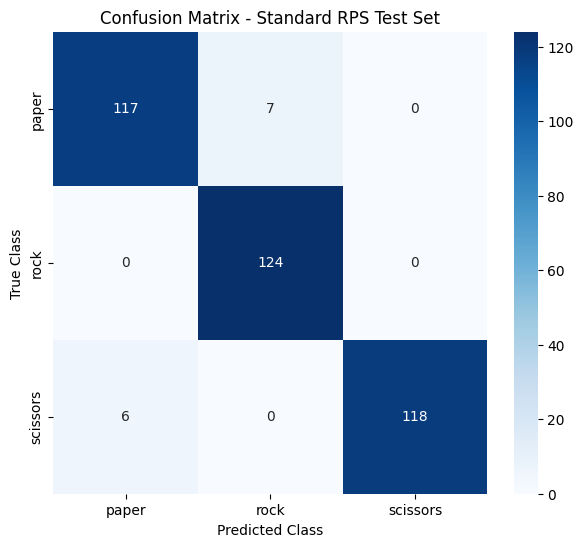

In [72]:
# ============================================================
# CELL 20: TEST SET EVALUATION
# ============================================================

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)


print("=" * 60)
print("STANDARD RPS TEST RESULTS")
print("=" * 60)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

In [73]:
# ============================================================
# CELL 21: TEST PREDICTIONS
# ============================================================

model.eval()


all_test_labels = []
all_test_predictions = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE
        )


        outputs = model(
            images
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        all_test_labels.extend(
            labels.numpy()
        )


        all_test_predictions.extend(
            predictions.cpu().numpy()
        )


all_test_labels = np.array(
    all_test_labels
)

all_test_predictions = np.array(
    all_test_predictions
)


print(
    "Test predictions:",
    len(all_test_predictions)
)

              precision    recall  f1-score   support

       paper     0.9512    0.9435    0.9474       124
        rock     0.9466    1.0000    0.9725       124
    scissors     1.0000    0.9516    0.9752       124

    accuracy                         0.9651       372
   macro avg     0.9659    0.9651    0.9650       372
weighted avg     0.9659    0.9651    0.9650       372



In [74]:
# ============================================================
# CELL 22: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)


plt.figure(
    figsize=(7, 6)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Confusion Matrix - RPS Test Set"
)

plt.show()

Number of incorrect test predictions: 13


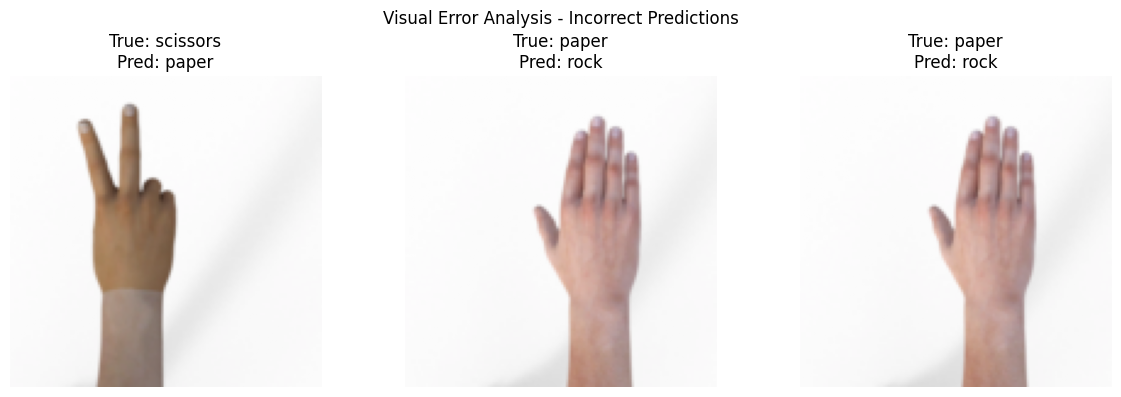

In [75]:
# ============================================================
# CELL 23: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

In [76]:
# ============================================================
# CELL 24: INCORRECT TEST PREDICTIONS
# ============================================================

incorrect_indices = np.where(
    all_test_labels
    !=
    all_test_predictions
)[0]


print(
    "Incorrect predictions:",
    len(incorrect_indices)
)

print(
    "Correct predictions:",
    len(all_test_labels)
    -
    len(incorrect_indices)
)

In [77]:
# ============================================================
# CELL 25: VISUAL ERROR ANALYSIS
# ============================================================

if len(incorrect_indices) > 0:

    number_to_show = min(
        3,
        len(incorrect_indices)
    )


    selected_indices = random.sample(
        list(incorrect_indices),
        number_to_show
    )


    plt.figure(
        figsize=(12, 5)
    )


    for i, dataset_index in enumerate(
        selected_indices
    ):


        image, true_label = test_dataset[
            dataset_index
        ]


        predicted_label = (
            all_test_predictions[
                dataset_index
            ]
        )


        image = denormalize(
            image
        )


        plt.subplot(
            1,
            number_to_show,
            i + 1
        )


        plt.imshow(
            image.permute(
                1,
                2,
                0
            )
        )


        plt.title(
            f"True: "
            f"{CLASS_NAMES[true_label]}\n"
            f"Pred: "
            f"{CLASS_NAMES[predicted_label]}"
        )


        plt.axis("off")


    plt.suptitle(
        "Visual Error Analysis"
    )


    plt.tight_layout()

    plt.show()

else:

    print(
        "No incorrect test images."
    )

CUSTOM IMAGE PREDICTIONS
paper1.jpg                -> paper      (89.65%)
paper2.jpg                -> rock       (99.86%)
paper3.jpg                -> rock       (64.83%)
rock1.jpg                 -> rock       (91.98%)
rock2.jpg                 -> rock       (99.95%)
rock3.jpg                 -> rock       (99.99%)
scissors1.jpg             -> paper      (59.73%)
scissors2.jpg             -> paper      (57.95%)
scissors3.jpg             -> scissors   (56.26%)
scissors4.jpg             -> rock       (97.43%)


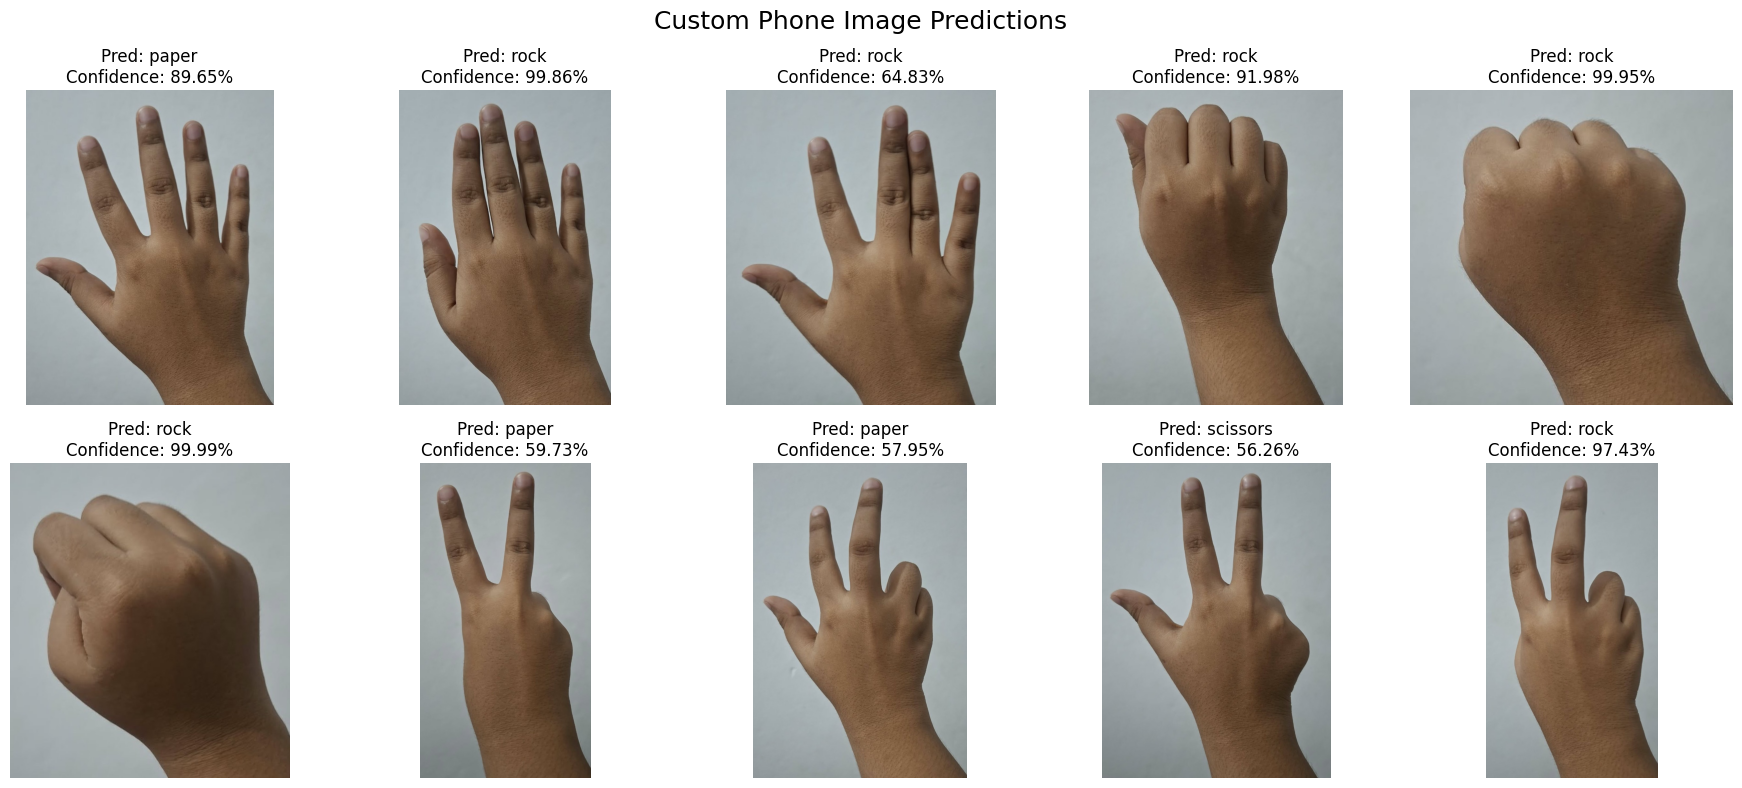

In [78]:
# ============================================================
# CELL 26: CUSTOM IMAGE PREDICTION
# ============================================================

def predict_custom_image(
    image_path
):

    # Load original image
    image = Image.open(
        image_path
    ).convert("RGB")


    # Apply same evaluation transform
    transformed_image = eval_transform(
        image
    )


    # Add batch dimension
    input_tensor = transformed_image.unsqueeze(
        0
    ).to(DEVICE)


    model.eval()


    with torch.no_grad():

        outputs = model(
            input_tensor
        )


        probabilities = torch.softmax(
            outputs,
            dim=1
        )


        confidence, predicted_index = torch.max(
            probabilities,
            dim=1
        )


    predicted_class = CLASS_NAMES[
        predicted_index.item()
    ]


    confidence_percentage = (
        confidence.item()
        * 100
    )


    return (
        image,
        predicted_class,
        confidence_percentage,
        probabilities.cpu().numpy()[0]
    )

In [79]:
# ============================================================
# CELL 27: CUSTOM IMAGE PREDICTIONS
# ============================================================

custom_results = []


for image_path in custom_images:

    (
        image,
        predicted_class,
        confidence,
        probabilities
    ) = predict_custom_image(
        image_path
    )


    custom_results.append({

        "path": image_path,

        "filename": os.path.basename(
            image_path
        ),

        "image": image,

        "predicted_class": predicted_class,

        "confidence": confidence,

        "probabilities": probabilities
    })


print("=" * 60)
print("CUSTOM PHONE IMAGE PREDICTIONS")
print("=" * 60)


for result in custom_results:

    print(
        f"{result['filename']:25s}"
        f" -> "
        f"{result['predicted_class']:10s}"
        f" "
        f"({result['confidence']:.2f}%)"
    )


paper1.jpg
paper     : 89.65%
rock      : 10.15%
scissors  : 0.19%

paper2.jpg
paper     : 0.14%
rock      : 99.86%
scissors  : 0.00%

paper3.jpg
paper     : 24.02%
rock      : 64.83%
scissors  : 11.15%

rock1.jpg
paper     : 8.02%
rock      : 91.98%
scissors  : 0.00%

rock2.jpg
paper     : 0.05%
rock      : 99.95%
scissors  : 0.00%

rock3.jpg
paper     : 0.01%
rock      : 99.99%
scissors  : 0.00%

scissors1.jpg
paper     : 59.73%
rock      : 30.08%
scissors  : 10.19%

scissors2.jpg
paper     : 57.95%
rock      : 40.32%
scissors  : 1.72%

scissors3.jpg
paper     : 39.36%
rock      : 4.38%
scissors  : 56.26%

scissors4.jpg
paper     : 2.09%
rock      : 97.43%
scissors  : 0.48%


In [80]:
# ============================================================
# CELL 28: CUSTOM PREDICTION GALLERY
# ============================================================

number_of_images = len(
    custom_results
)

columns = 5

rows = int(
    np.ceil(
        number_of_images
        /
        columns
    )
)


plt.figure(
    figsize=(18, 4 * rows)
)


for i, result in enumerate(
    custom_results
):

    plt.subplot(
        rows,
        columns,
        i + 1
    )


    plt.imshow(
        result["image"]
    )


    plt.title(
        f"Pred: "
        f"{result['predicted_class']}\n"
        f"Confidence: "
        f"{result['confidence']:.2f}%"
    )


    plt.axis("off")


plt.suptitle(
    "Custom Phone Image Predictions",
    fontsize=18
)


plt.tight_layout()

plt.show()

CNN ROCK-PAPER-SCISSORS CLASSIFICATION - FINAL RESULTS

Device: cpu

Standard Test Accuracy:
96.51%

Custom Image Predictions:
  paper1.jpg -> paper (89.65%)
  paper2.jpg -> rock (99.86%)
  paper3.jpg -> rock (64.83%)
  rock1.jpg -> rock (91.98%)
  rock2.jpg -> rock (99.95%)
  rock3.jpg -> rock (99.99%)
  scissors1.jpg -> paper (59.73%)
  scissors2.jpg -> paper (57.95%)
  scissors3.jpg -> scissors (56.26%)
  scissors4.jpg -> rock (97.43%)

Model file:
/content/220142_CNN_RPS/model/rps_cnn.pth

Number of custom images:
10

Classes:
paper, rock, scissors

Assignment pipeline completed.


In [81]:
# ============================================================
# CELL 29: CUSTOM IMAGE PROBABILITIES
# ============================================================

for result in custom_results:

    print("\n" + "=" * 50)

    print(
        result["filename"]
    )

    print("=" * 50)


    for class_name, probability in zip(
        CLASS_NAMES,
        result["probabilities"]
    ):

        print(
            f"{class_name:10s}: "
            f"{probability * 100:.2f}%"
        )

ASSIGNMENT REQUIREMENT CHECK
[PASS] GitHub repository cloned automatically
[PASS] Custom dataset exists
[PASS] 10 custom images
[PASS] CNN uses nn.Module
[PASS] Conv2d used
[PASS] ReLU used
[PASS] MaxPool2d used
[PASS] Linear used
[PASS] Model .pth exists
[PASS] Standard test evaluation completed
[PASS] Confusion matrix generated
[PASS] Custom predictions completed

Done.


In [ ]:
# ============================================================
# CELL 30: FINAL RESULTS
# ============================================================

print("=" * 70)

print(
    "RESNET18 ROCK-PAPER-SCISSORS "
    "CLASSIFICATION - FINAL RESULTS"
)

print("=" * 70)


print(
    "\nDevice:",
    DEVICE
)


print(
    "\nStandard Test Accuracy:",
    f"{test_accuracy:.2f}%"
)


print(
    "\nCustom Image Predictions:"
)


for result in custom_results:

    print(
        f"  {result['filename']}"
        f" -> "
        f"{result['predicted_class']}"
        f" "
        f"({result['confidence']:.2f}%)"
    )


print(
    "\nModel file:"
)

print(
    MODEL_PATH
)


print(
    "\nNumber of custom images:",
    len(custom_results)
)


print(
    "\nClasses:",
    ", ".join(CLASS_NAMES)
)


print(
    "\nAssignment pipeline completed."
)

In [ ]:
# ============================================================
# CELL 31: ASSIGNMENT REQUIREMENT CHECK
# ============================================================

checks = {

    "GitHub repository cloned":
        os.path.exists(REPO_DIR),

    "Custom dataset exists":
        os.path.exists(CUSTOM_DATA_DIR),

    "10 custom images":
        len(custom_images) == 10,

    "CNN inherits from nn.Module":
        isinstance(model, nn.Module),

    "ResNet18 used":
        hasattr(model, "resnet"),

    "Linear layer used":
        any(
            isinstance(
                layer,
                nn.Linear
            )
            for layer in model.modules()
        ),

    "Model .pth exists":
        os.path.exists(MODEL_PATH),

    "Test predictions generated":
        len(all_test_predictions) > 0,

    "Confusion matrix generated":
        cm.shape == (3, 3),

    "Custom predictions generated":
        len(custom_results)
        == len(custom_images)
}


print("=" * 65)

print(
    "ASSIGNMENT REQUIREMENT CHECK"
)

print("=" * 65)


for requirement, status in checks.items():

    if status:

        print(
            "[PASS]",
            requirement
        )

    else:

        print(
            "[FAIL]",
            requirement
        )


print("\nDone.")